<h1> 9.0 Performance Programming <h1>

In [1]:
def series1(start, iterations=4):
    """Returns the value of the series after the provided number of iterations."""
    value = start
    for _ in range(iterations):
        value = value**2

    return value


assert series1(0) == 0
assert series1(1) == 1
assert series1(-2) == 65536

In [2]:
xmin = -2
xmax = 2
resolution = 300
xstep = (xmax - xmin) / resolution
xs = [(xmin + (xstep * i)) for i in range(resolution)]  # list of starting points

In [3]:
zs = [series1(x) for x in xs]

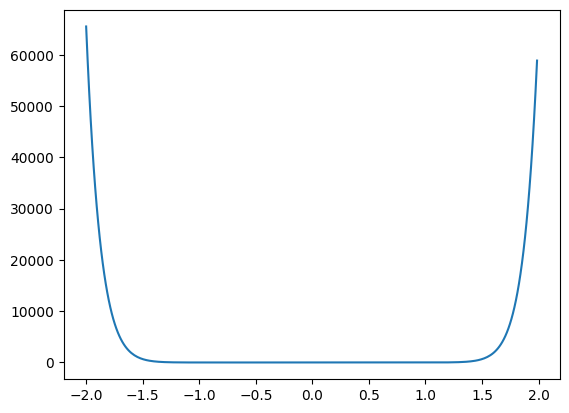

In [4]:
import matplotlib.pyplot as plt

plt.plot(xs, zs)

In [5]:
def series2(start, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations.

    The function stops when the value of the series surpasses a threshold or when it reaches the maximum
    number of iterations.

    Returns the number of iterations.
    """
    value = start

    counter = 0

    while counter < max_iterations:
        # Arbitrary threshold, for now
        if abs(value) > 2:
            break

        value = value**2

        counter = counter + 1

    return counter


assert series2(0) == 50
assert series2(1) == 50
assert series2(2) == 1
assert series2(1.5) == 1

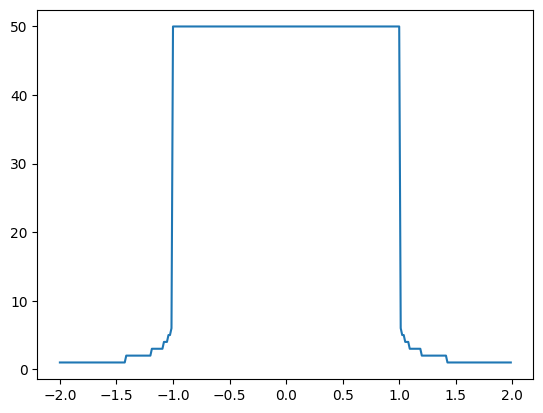

In [6]:
zs = [series2(x) for x in xs]
plt.plot(xs, zs)

In [7]:
# Option 1
c = complex(5, 6)

In [8]:
# Option 2
d = 5 + 1j * 6

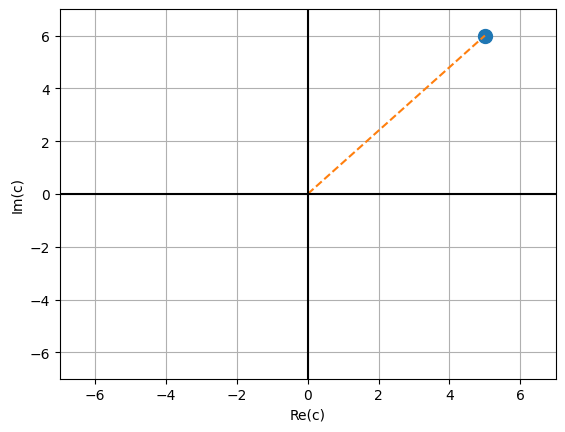

In [9]:
plt.plot(c.real, c.imag, marker="o", markersize=10)
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.plot([0, c.real], [0, c.imag], "--")
plt.plot([-7, 7], [0, 0], color="black")
plt.plot([0, 0], [-7, 7], color="black")
plt.grid()

In [10]:
abs(c)

7.810249675906654

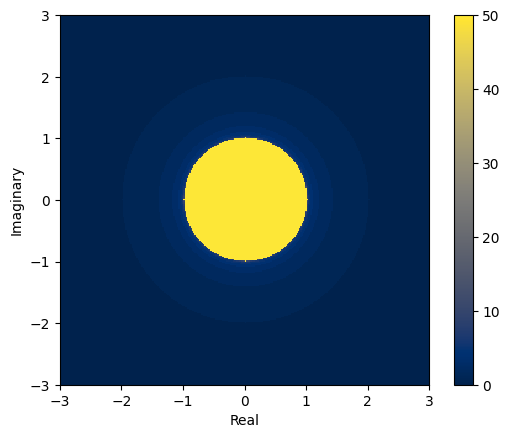

In [11]:
# we need some complex starting points
xmin = -3
ymin = -3
xmax = 3
ymax = 3
resolution = 300
xstep = (xmax - xmin) / resolution
ystep = (ymax - ymin) / resolution
xs = [(xmin + xstep * i) for i in range(resolution)]
ys = [(ymin + ystep * i) for i in range(resolution)]
zs = [[series2(x + y * 1j) for x in xs] for y in ys]

plt.set_cmap("cividis")  # use a color vision deficiency-friendly palette
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.imshow(zs, interpolation="none", extent=[xmin, xmax, ymin, ymax], origin="lower")
plt.colorbar()

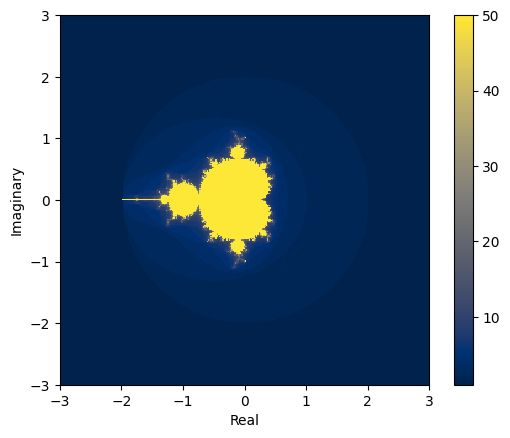

In [12]:
def mandel(constant, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations.

    The function stops when the absolute value of the series surpasses 2 or when it reaches the maximum
    number of iterations.

    Returns the number of iterations.
    """

    value = 0

    counter = 0
    while counter < max_iterations:
        if abs(value) > 2:
            break

        value = (value**2) + constant

        counter = counter + 1

    return counter


assert mandel(0) == 50
assert mandel(3) == 1
assert mandel(0.5) == 5

plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.imshow(
    [[mandel(x + y * 1j) for x in xs] for y in ys],
    interpolation="none",
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
)
plt.colorbar()

In [13]:
# Fractals
xmin = -1
ymin = -1
xmax = 0
ymax = 0
resolution = 300
xstep = (xmax - xmin) / resolution
ystep = (ymax - ymin) / resolution
xs = [(xmin + xstep * i) for i in range(resolution)]
ys = [(ymin + ystep * i) for i in range(resolution)]
zs = [[mandel(x + y * 1j) for x in xs] for y in ys]

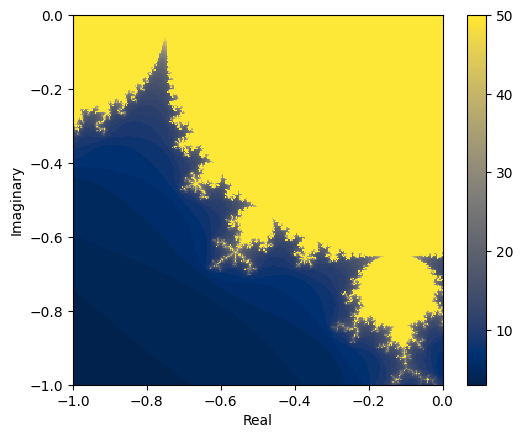

In [14]:
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.imshow(zs, interpolation="none", extent=[xmin, xmax, ymin, ymax], origin="lower")
plt.colorbar()

In [18]:
%%timeit -n 3 -r 7 value=10
# timeit results are only useful as comparisons
# the absolute values are not meaningful
# variables created in timeit cells aren't available outside
value**value

127 ns ± 93.7 ns per loop (mean ± std. dev. of 7 runs, 3 loops each)


In [19]:
%%timeit
[[mandel(x + y * 1j) for x in xs] for y in ys]

375 ms ± 142 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


<h1> 9.2 Optimising with NumPy <h1>

In [20]:
xmin = -1.5
ymin = -1.0
xmax = 0.5
ymax = 1.0
resolution = 300
xstep = (xmax - xmin) / resolution
ystep = (ymax - ymin) / resolution
xs = [(xmin + xstep * i) for i in range(resolution)]
ys = [(ymin + ystep * i) for i in range(resolution)]
# list with complex values
cs_listcomp = [[(x + y * 1j) for x in xs] for y in ys]

In [21]:
import numpy as np
cs = np.asarray(cs_listcomp)
cs.shape

(300, 300)

In [22]:
# we need to make copies of array to avoid overwriting it
cs_loop = cs.copy()
cs_numpy = cs.copy()

In [23]:
%%timeit
for i in range(cs_loop.shape[0]):
    for j in range(cs_loop.shape[1]):
        cs_loop[i][j] = cs_loop[i][j] + 10

32.4 ms ± 7.32 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [24]:
%%timeit
cs_numpy + 10

60.5 µs ± 23.1 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [25]:
import math

math.sqrt(cs)

TypeError: only length-1 arrays can be converted to Python scalars

In [26]:
np.sqrt(cs)

array([[0.38908588-1.28506335j, 0.38980707-1.28268581j,
        0.39053184-1.28030535j, ..., 0.89141291-0.56090729j,
        0.89409221-0.55922644j, 0.8967725 -0.55755501j],
       [0.38670802-1.2843454j , 0.38742629-1.2819643j ,
        0.38814812-1.27958025j, ..., 0.88972681-0.55822378j,
        0.89241558-0.55654191j, 0.89510532-0.55486953j],
       [0.38432663-1.28363038j, 0.38504193-1.28124573j,
        0.3857608 -1.27885811j, ..., 0.88803965-0.55553075j,
        0.89073797-0.55384788j, 0.89343724-0.55217458j],
       ...,
       [0.38194169+1.28291834j, 0.38265402+1.28053014j,
        0.3833699 +1.27813894j, ..., 0.88635146+0.55282811j,
        0.88905943+0.55114426j, 0.8917683 +0.54947008j],
       [0.38432663+1.28363038j, 0.38504193+1.28124573j,
        0.3857608 +1.27885811j, ..., 0.88803965+0.55553075j,
        0.89073797+0.55384788j, 0.89343724+0.55217458j],
       [0.38670802+1.2843454j , 0.38742629+1.2819643j ,
        0.38814812+1.27958025j, ..., 0.88972681+0.55822378j,
 

In [27]:
# Attempt 1: Binary Mandelbrot
z0 = cs
z1 = z0 * z0 + cs
z2 = z1 * z1 + cs
z3 = z2 * z2 + cs

In [28]:
def mandel(constant, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations.

    The function stops when the absolute value of the series surpasses 2 or when it reaches the maximum
    number of iterations.

    Returns the number of iterations.
    """

    value = 0

    counter = 0
    while counter < max_iterations:
        if abs(value) > 2:
            break

        value = (value * value) + constant

        counter = counter + 1

    return counter


assert mandel(0) == 50
assert mandel(3) == 1
assert mandel(0.5) == 5

mandel(cs)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [29]:
def mandel_numpy_explode(constants, max_iterations=50):
    """Has the series diverged after all iterations?

    Returns an array with True if the series doesn't explode and False otherwise.
    """
    value = np.zeros(constants.shape)

    counter = 0
    while counter < max_iterations:

        value = (value * value) + constants

        counter = counter + 1

    return abs(value) < 2

In [30]:
result_numpy_explode = mandel_numpy_explode(cs)

/var/folders/j7/2lnv016s5qn2r5lcrf2bk7080000gn/T/ipykernel_91794/3776945222.py:11: RuntimeWarning: overflow encountered in multiply
  value = (value * value) + constants
/var/folders/j7/2lnv016s5qn2r5lcrf2bk7080000gn/T/ipykernel_91794/3776945222.py:11: RuntimeWarning: invalid value encountered in multiply
  value = (value * value) + constants


In [31]:
# Attempt 2: Return iteration
def mandel_numpy(constants, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations.

    The function stops values from exploding once diverged.

    Returns the number of iterations.
    """

    value = np.zeros(constants.shape)
    # An array which keeps track of the first step at which each position diverged
    diverged_at_count = np.ones(constants.shape) * max_iterations
    counter = 0
    while counter < max_iterations:
        value = value * value + constants
        diverging = abs(value) > 2

        # Any positions which are:
        # - diverging
        # - haven't diverged before
        # are diverging for the first time
        first_diverged_this_time = np.logical_and(
            diverging, diverged_at_count == max_iterations
        )

        # Update diverged_at_count for all positions which first diverged at this step
        diverged_at_count[first_diverged_this_time] = counter
        # Reset any divergent values to exactly 2
        value[diverging] = 2
        counter = counter + 1

    return diverged_at_count


assert mandel_numpy(np.asarray([0])) == np.asarray([50])
assert mandel_numpy(np.asarray([4])) == np.asarray([0])

In [32]:
%%timeit
mandel_numpy(cs)

31.2 ms ± 12 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [33]:
result_numpy = mandel_numpy(cs)

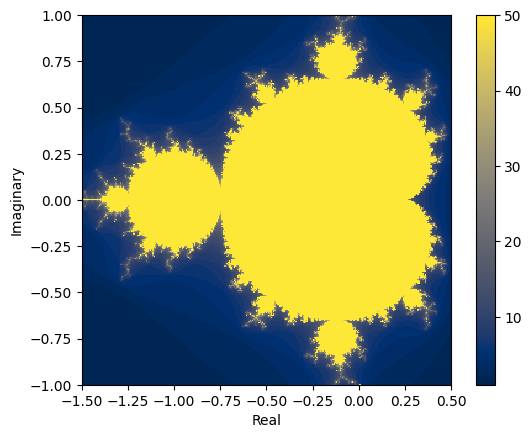

In [34]:
import matplotlib.pyplot as plt

plt.set_cmap("cividis")
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.imshow(
    result_numpy, interpolation="none", extent=[xmin, xmax, ymin, ymax], origin="lower"
)
plt.colorbar()

<h1> 9.3 Cython <h1>

In [37]:
%load_ext Cython

In [38]:
%%cython

def mandel_cython():
    value = 0

Content of stderr:
ld: warning: duplicate -rpath '/Users/yuxinliu/anaconda3/lib' ignored

In [39]:
mandel_cython()

In [40]:
%%cython

def mandel_cython(constant, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations. 
    
    The function stops when the absolute value of the series surpasses 2 or when it reaches the maximum 
    number of iterations.
    
    Returns the number of iterations.
    """
    
    value = 0

    counter = 0
    while counter < max_iterations:
        if abs(value) > 2:
            break

        value = (value * value) + constant

        counter = counter + 1

    return counter


assert mandel_cython(0) == 50
assert mandel_cython(3) == 1
assert mandel_cython(0.5) == 5

Content of stderr:
ld: warning: duplicate -rpath '/Users/yuxinliu/anaconda3/lib' ignored

In [42]:
data_python = [[mandel(x + 1j * y) for x in xs] for y in ys]
data_cython = [[mandel_cython(x + 1j * y) for x in xs] for y in ys]

<Figure size 640x480 with 0 Axes>

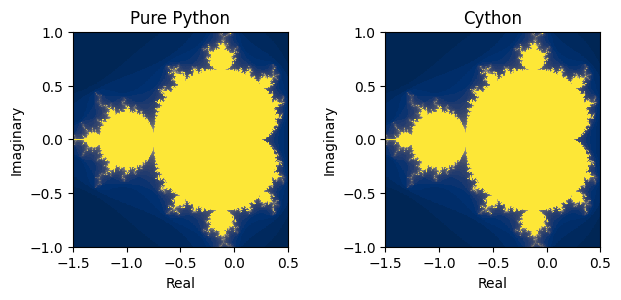

In [43]:
from matplotlib import pyplot as plt

plt.set_cmap("cividis")  # use a CVD-friendly palette

f, axarr = plt.subplots(1, 2)
axarr[0].imshow(data_python, interpolation="none", extent=[xmin, xmax, ymin, ymax])
axarr[0].set_title("Pure Python")
axarr[0].set_ylabel("Imaginary")
axarr[0].set_xlabel("Real")
axarr[1].imshow(data_cython, interpolation="none", extent=[xmin, xmax, ymin, ymax])
axarr[1].set_title("Cython")
axarr[1].set_ylabel("Imaginary")
axarr[1].set_xlabel("Real")
f.tight_layout()

In [44]:
%%timeit
[[mandel(x + 1j * y) for x in xs] for y in ys]  # pure python

388 ms ± 151 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [45]:
%%timeit
[[mandel_cython(x + 1j * y) for x in xs] for y in ys]  # cython

250 ms ± 62 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [46]:
%%cython --annotate

def mandel_cython(constant, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations. 
    
    The function stops when the absolute value of the series surpasses 2 or when it reaches the maximum 
    number of iterations.
    
    Returns the number of iterations.
    """
    
    value = 0

    counter = 0
    while counter < max_iterations:
        if abs(value) > 2:
            break

        value = (value * value) + constant

        counter = counter + 1

    return counter

Content of stderr:
ld: warning: duplicate -rpath '/Users/yuxinliu/anaconda3/lib' ignored

In [47]:
%%cython

def mandel_cython_var_typed(constant, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations. 
    
    The function stops when the absolute value of the series surpasses 2 or when it reaches the maximum 
    number of iterations.
    
    Returns the number of iterations.
    """
    cdef double complex value # typed variable
    value = 0

    counter = 0
    while counter < max_iterations:
        if abs(value) > 2:
            break

        value = (value * value) + constant

        counter = counter + 1

    return counter


assert mandel_cython_var_typed(0) == 50
assert mandel_cython_var_typed(3) == 1
assert mandel_cython_var_typed(0.5) == 5

Content of stderr:
ld: warning: duplicate -rpath '/Users/yuxinliu/anaconda3/lib' ignored

In [48]:
%%timeit
[[mandel_cython_var_typed(x + 1j * y) for x in xs] for y in ys]

236 ms ± 53.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [49]:
%%cython

cpdef int mandel_cython_func_typed(double complex constant, int max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations. 
    
    The function stops when the absolute value of the series surpasses 2 or when it reaches the maximum 
    number of iterations.
    
    Returns the number of iterations.
    """
    cdef double complex value # typed variable
    value = 0

    cdef int counter = 0
    while counter < max_iterations:
        if abs(value) > 2:
            break

        value = (value * value) + constant

        counter = counter + 1

    return counter


assert mandel_cython_func_typed(0) == 50
assert mandel_cython_func_typed(3) == 1
assert mandel_cython_func_typed(0.5) == 5

Content of stderr:
ld: warning: duplicate -rpath '/Users/yuxinliu/anaconda3/lib' ignored

In [50]:
%%timeit
[[mandel_cython_func_typed(x + 1j * y) for x in xs] for y in ys]

31.7 ms ± 9.92 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [51]:
import numpy as np

cs_listcomp = [[(x + 1j * y) for x in xs] for y in ys]
cs = np.asarray(cs_listcomp)

In [52]:
%%cython

import numpy as np
cimport numpy as np 

cpdef int mandel_cython_numpy(np.ndarray[double complex, ndim=2] constants, int max_iterations=50): 
    cdef np.ndarray[long,ndim=2] diverged_at_count
    cdef np.ndarray[double complex, ndim=2] value
    cdef int counter

    diverged_at_count = np.ones((constants.shape[0], constants.shape[1]), dtype=int)*max_iterations
    value = np.zeros((constants.shape[0], constants.shape[1]), dtype=complex)
    counter = 0
    while counter < max_iterations:
        value = value*value + constants
        diverging = abs(value) > 2
        
        # Any positions which are:
        # - diverging
        # - haven't diverged before
        # are diverging for the first time
        first_diverged_this_time = np.logical_and(
            diverging,
            diverged_at_count == max_iterations
        )
        
        # Update diverged_at_count for all positions which first diverged at this step
        diverged_at_count[first_diverged_this_time] = counter
        # Reset any divergent values to exactly 2
        value[diverging] = 2
        counter = counter + 1

    return diverged_at_count

assert mandel_cython_numpy(np.asarray([[0 + 1j*0]])) == np.asarray([[50]])
assert mandel_cython_numpy(np.asarray([[4 + 1j*0]])) == np.asarray([[0]])

Content of stderr:
In file included from /Users/yuxinliu/.cache/ipython/cython/_cython_magic_6bc915d02ad68d9e9143aba66a5d2bd3b1f5846e2f35ca77f78f92e52a3dae09.c:1148:
In file included from /Users/yuxinliu/anaconda3/lib/python3.11/site-packages/numpy/core/include/numpy/arrayobject.h:5:
In file included from /Users/yuxinliu/anaconda3/lib/python3.11/site-packages/numpy/core/include/numpy/ndarrayobject.h:12:
In file included from /Users/yuxinliu/anaconda3/lib/python3.11/site-packages/numpy/core/include/numpy/ndarraytypes.h:1929:
/Users/yuxinliu/anaconda3/lib/python3.11/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: "Using deprecated NumPy API, disable it with "          "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-W#warnings]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^
1 warning generated.
ld: warning: duplicate -rpath '/Users/yuxinliu/anaconda3/lib' ignored

In [53]:
%%timeit
mandel_cython_numpy(cs)

TypeError: only length-1 arrays can be converted to Python scalars

<h1> 9.4 Optimising with Numba <h1>

In [54]:
%%timeit

[[mandel(x + 1j * y) for x in xs] for y in ys]

314 ms ± 101 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [55]:
import numpy as np
from matplotlib import pyplot as plt
from numba import njit

@njit
def mandel_numba(constant, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations.

    The function stops when the absolute value of the series surpasses 2 or when it reaches the maximum
    number of iterations.

    Returns the number of iterations.
    """

    value = 0

    counter = 0
    while counter < max_iterations:
        if abs(value) > 2:
            break

        value = (value * value) + constant

        counter = counter + 1

    return counter

In [56]:
%%timeit -r 1 -n 1

mandel_numba(complex(0, 0))

965 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [57]:
# Run after our first, timed, invocation
assert mandel_numba(0) == 50
assert mandel_numba(3) == 1
assert mandel_numba(0.5) == 5

In [58]:
%%timeit
[[mandel_numba(x + 1j * y) for x in xs] for y in ys]

54.5 ms ± 17.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [59]:
data_numba = [[mandel_numba(complex(x, y)) for x in xs] for y in ys]

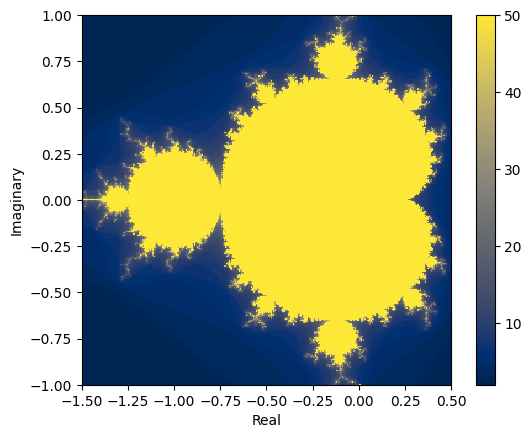

In [60]:
plt.set_cmap("cividis")  # use a color vision deficiency-friendly palette
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.imshow(
    data_numba, interpolation="none", extent=[xmin, xmax, ymin, ymax], origin="lower"
)
plt.colorbar()

In [61]:
from os import cpu_count

cpu_count()

8

In [62]:
%%writefile sleeping.py

from time import sleep

def square(argument):
    sleep(0.5)
    return argument * argument

Writing sleeping.py


In [63]:
import importlib

import sleeping

importlib.reload(sleeping)

<module 'sleeping' from '/Users/yuxinliu/Desktop/M2/Python-Learning/9. Programming for Speed/sleeping.py'>

In [64]:
assert list(map(sleeping.square, [0, 1, 2, 3])) == [0, 1, 4, 9]

In [65]:
%%timeit -n 2 -r 2

list(map(sleeping.square, [0, 1, 2, 3, 4, 5, 6, 7, 8]))

4.53 s ± 850 µs per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [66]:
from multiprocessing import Pool

with Pool() as pool:
    results = pool.map(sleeping.square, [1, 2, 3, 4, 5, 6, 7, 8])
results

[1, 4, 9, 16, 25, 36, 49, 64]

In [67]:
%%timeit pool = Pool()

pool.map(sleeping.square, [1, 2, 3, 4, 5, 6, 7, 8])

644 ms ± 73.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [68]:
pool.close()

In [69]:
from numba import prange

help(prange)

Help on class prange in module numba.misc.special:

class prange(builtins.object)
 |  prange(*args)
 |  
 |  Provides a 1D parallel iterator that generates a sequence of integers.
 |  In non-parallel contexts, prange is identical to range.
 |  
 |  Static methods defined here:
 |  
 |  __new__(cls, *args)
 |      Create and return a new object.  See help(type) for accurate signature.
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for instance variables (if defined)
 |  
 |  __weakref__
 |      list of weak references to the object (if defined)


In [70]:
@njit(parallel=True)
def mandel_numba_parallel(constants, max_iterations=50):
    """Computes the values of the series for up to a maximum number of iterations.

    Returns the number of iterations.
    """
    xlim = constants.shape[1]
    ylim = constants.shape[0]

    diverged_at_count = np.zeros((ylim, xlim))

    for y in prange(ylim):
        for x in prange(xlim):

            value = 0
            counter = 0

            while counter < max_iterations:
                if abs(value) > 2:
                    break

                value = (value * value) + constants[y, x]

                counter = counter + 1

            diverged_at_count[y, x] = counter

    return diverged_at_count

In [71]:
assert mandel_numba_parallel(np.asarray([[0]])) == np.asarray([[50]])
assert mandel_numba_parallel(np.asarray([[4]])) == np.asarray([[1]])

In [72]:
cs_listcomp = [[(x + y * 1j) for x in xs] for y in ys]
cs = np.asarray(cs_listcomp)

In [73]:
%%timeit
mandel_numba_parallel(cs)

7.67 ms ± 3.32 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [74]:
zs = mandel_numba_parallel(cs)

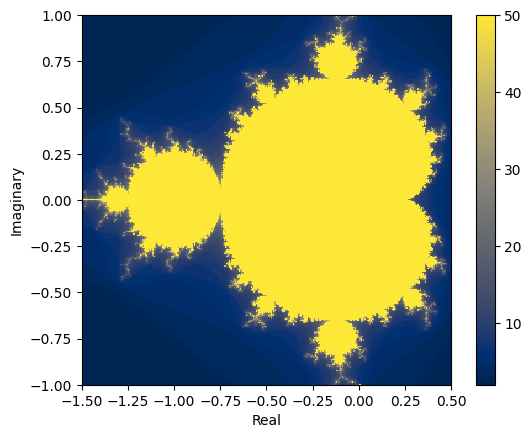

In [75]:
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.imshow(zs, interpolation="none", extent=[xmin, xmax, ymin, ymax], origin="lower")
plt.colorbar()

<h1> 9.5 Performance Scaling for Containers and Algorithms <h1>

In [76]:
from timeit import repeat

import numpy as np
from matplotlib import pyplot as plt

In [78]:
def time_append_to_ndarray(count):
    # the function repeat does the same that the `%timeit` magic
    # but as a function; so we can plot it.
    return repeat(
        "np.append(before, [0])",
        f"import numpy as np; before=np.ndarray({count})",
        number=10000,
    )

help(repeat)

Help on function repeat in module timeit:

repeat(stmt='pass', setup='pass', timer=<built-in function perf_counter>, repeat=5, number=1000000, globals=None)
    Convenience function to create Timer object and call repeat method.


In [79]:
def time_append_to_list(count):
    return repeat("before.append(0)", f"before = [0] * {count}", number=10000)

In [80]:
counts = np.arange(1, 100000, 10000)


def plot_time(function, counts, title=None, top=None):
    plt.plot(counts, list(map(function, counts)))
    plt.ylim(bottom=0, top=top)
    plt.ylabel("seconds")
    plt.xlabel("array size")
    plt.title(title or function.__name__)

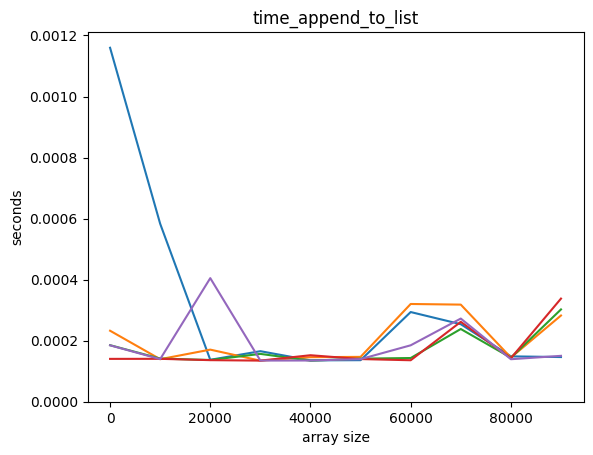

In [81]:
plot_time(time_append_to_list, counts)

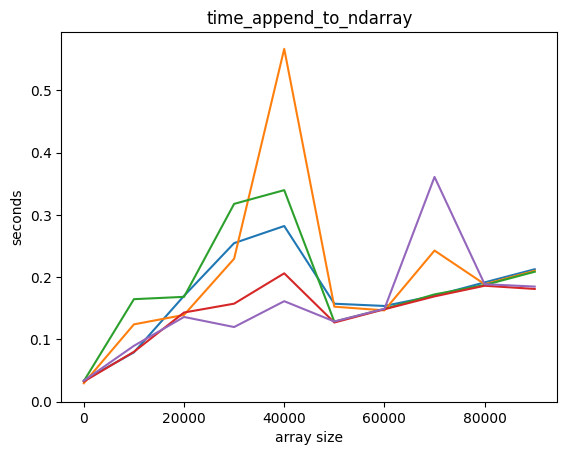

In [82]:
plot_time(time_append_to_ndarray, counts)